In [ ]:
from google.colab import drive
drive.mount('/content/drive')
exec(open("/content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier/00_colab_setup.py").read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ /content/drive/MyDrive/imdb_peft_project
✓ /content/drive/MyDrive/imdb_peft_project/checkpoints/roberta_lora
✓ /content/drive/MyDrive/imdb_peft_project/checkpoints/deberta_lora
✓ /content/drive/MyDrive/imdb_peft_project/oof_predictions
✓ /content/drive/MyDrive/imdb_peft_project/results
✓ /content/drive/MyDrive/imdb_peft_project/notebooks
✓ /content/drive/MyDrive/imdb_peft_project/code

Folder structure ready.
Enter GitHub Token: ··········
Repository exists, pulling latest changes...
✓ Pull complete.

Repository path: /content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier
SETUP COMPLETE
Drive folder  : /content/drive/MyDrive/imdb_peft_project
GitHub repo   : /content/drive/MyDrive/imdb_peft_project/code/lora-imdb-class

In [ ]:
!pip install transformers peft accelerate torchao --upgrade -q
!pip install scikit-learn numpy pandas xgboost safetensors -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import os
import safetensors.torch as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)
from transformers import (RobertaTokenizer, RobertaForSequenceClassification,
                          DebertaV2Tokenizer, DebertaV2ForSequenceClassification,
                          Trainer, TrainingArguments)
from peft import PeftModel, LoraConfig, get_peft_model, TaskType
from torch.utils.data import Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
# Define paths
DIRS["oof_v2"]      = f"{DIRS['root']}/oof_predictions_v2"
DIRS["oof_v2_best"] = f"{DIRS['root']}/oof_predictions_v2_best"
DIRS["checkpoints_v2"]    = f"{DIRS['root']}/checkpoints/roberta_lora_v2"
DIRS["checkpoints2_best"] = f"{DIRS['root']}/checkpoints/deberta_lora_v2_best"

# Load data
train_df = pd.read_parquet(f"{DIRS['root']}/train_df_v2.parquet")
test_df  = pd.read_parquet(f"{DIRS['root']}/test_df_v2.parquet")
y_train  = train_df["label"].values
y_test   = test_df["label"].values

# Load RoBERTa and DeBERTa OOF
roberta_oof = np.load(f"{DIRS['oof_v2']}/roberta_v2_fold4.npy")
deberta_oof = np.load(f"{DIRS['oof_v2_best']}/deberta_v2_best_fold4.npy")

# Load TF-IDF OOF
svm_oof = np.load(f"{DIRS['oof_v2']}/tfidf_svm_oof.npy")
lr_oof  = np.load(f"{DIRS['oof_v2']}/tfidf_lr_oof.npy")

print(f"RoBERTa OOF : {roberta_oof.shape}")
print(f"DeBERTa OOF : {deberta_oof.shape}")
print(f"SVM OOF     : {svm_oof.shape}")
print(f"LR OOF      : {lr_oof.shape}")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

RoBERTa OOF : (25000,)
DeBERTa OOF : (25000,)
SVM OOF     : (25000,)
LR OOF      : (25000,)
Train: 25000 | Test: 25000


In [ ]:
def head_tail_truncate_v2(text, tokenizer, max_len=512, head_len=256):
    """V2: Equal split — first 256 + last 256 tokens."""
    tail_len = max_len - head_len
    tokens = tokenizer(text, add_special_tokens=False,
                       truncation=False, return_tensors=None)
    input_ids      = tokens["input_ids"]
    attention_mask = tokens["attention_mask"]
    if len(input_ids) > max_len - 2:
        input_ids      = input_ids[:head_len] + input_ids[-tail_len:]
        attention_mask = attention_mask[:head_len] + attention_mask[-tail_len:]
    return tokenizer(
        tokenizer.decode(input_ids),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors=None
    )

class IMDBDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512, head_len=256):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.head_len  = head_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text  = self.df.loc[idx, "text_clean"]
        label = self.df.loc[idx, "label"]
        encoding = head_tail_truncate_v2(
            text, self.tokenizer, self.max_len, self.head_len
        )
        return {
            "input_ids":      torch.tensor(encoding["input_ids"],      dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"], dtype=torch.long),
            "labels":         torch.tensor(label,                      dtype=torch.long),
        }

print("✓ Dataset class ready.")

✓ Dataset class ready.


In [ ]:
print("Loading RoBERTa V2...")
roberta_tokenizer    = RobertaTokenizer.from_pretrained("roberta-base")
roberta_test_dataset = IMDBDataset(test_df, roberta_tokenizer)

base_model    = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
roberta_model = PeftModel.from_pretrained(base_model, f"{DIRS['checkpoints_v2']}/final")
roberta_model.eval()
print("✓ RoBERTa V2 loaded.")

training_args = TrainingArguments(
    output_dir="/tmp/eval_r", per_device_eval_batch_size=64, report_to="none"
)
trainer = Trainer(model=roberta_model, args=training_args)
preds_output       = trainer.predict(roberta_test_dataset)
roberta_test_probs = torch.softmax(
    torch.tensor(preds_output.predictions), dim=-1
)[:, 1].numpy()

print(f"✓ RoBERTa test predictions ready. Shape: {roberta_test_probs.shape}")

# Save to Drive
np.save(f"{DIRS['oof_v2']}/roberta_test_probs.npy", roberta_test_probs)
print("✓ Saved to Drive.")

del roberta_model, trainer
torch.cuda.empty_cache()

Loading RoBERTa V2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ RoBERTa V2 loaded.


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (544 > 512). Running this sequence through the model will result in indexing errors
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


✓ RoBERTa test predictions ready. Shape: (25000,)
✓ Saved to Drive.


In [ ]:
print("Loading DeBERTa V2 Best...")
deberta_tokenizer    = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-base")
deberta_test_dataset = IMDBDataset(test_df, deberta_tokenizer)

base_model = DebertaV2ForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["query_proj", "value_proj"],
    bias="none"
)
deberta_model = get_peft_model(base_model, lora_config)

epoch3_path = f"{DIRS['checkpoints2_best']}/epoch_3"
weights     = st.load_file(f"{epoch3_path}/adapter_model.safetensors")
extra       = torch.load(f"{epoch3_path}/extra_weights.pt", map_location="cpu")

new_weights = {}
for k, v in weights.items():
    if "lora_A.weight" in k:
        new_weights[k.replace("lora_A.weight", "lora_A.default.weight")] = v
    elif "lora_B.weight" in k:
        new_weights[k.replace("lora_B.weight", "lora_B.default.weight")] = v

new_weights["base_model.model.classifier.modules_to_save.default.weight"] = extra["classifier.weight"]
new_weights["base_model.model.classifier.modules_to_save.default.bias"]   = extra["classifier.bias"]
new_weights["base_model.model.classifier.original_module.weight"]          = extra["classifier.weight"]
new_weights["base_model.model.classifier.original_module.bias"]            = extra["classifier.bias"]
new_weights["base_model.model.pooler.dense.weight"]                        = extra["pooler.weight"]
new_weights["base_model.model.pooler.dense.bias"]                          = extra["pooler.bias"]

deberta_model.load_state_dict(new_weights, strict=False)
deberta_model = deberta_model.to(torch.float32).to(device)
deberta_model.eval()
print("✓ DeBERTa V2 Best loaded.")

training_args = TrainingArguments(
    output_dir="/tmp/eval_d", per_device_eval_batch_size=32, report_to="none"
)
trainer = Trainer(model=deberta_model, args=training_args)
preds_output        = trainer.predict(deberta_test_dataset)
deberta_test_probs  = torch.softmax(
    torch.tensor(preds_output.predictions), dim=-1
)[:, 1].numpy()

print(f"✓ DeBERTa test predictions ready. Shape: {deberta_test_probs.shape}")

# Save to Drive
np.save(f"{DIRS['oof_v2']}/deberta_test_probs.npy", deberta_test_probs)
print("✓ Saved to Drive.")

del deberta_model, trainer
torch.cuda.empty_cache()

Loading DeBERTa V2 Best...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.den

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

✓ DeBERTa V2 Best loaded.


✓ DeBERTa test predictions ready. Shape: (25000,)
✓ Saved to Drive.


In [ ]:
# Retrain TF-IDF models on full training set
print("Training TF-IDF models on full training set...")

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df["text_clean_lower"])
X_test_tfidf  = tfidf.transform(test_df["text_clean_lower"])

# Calibrated SVM
svm_final = CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3)
svm_final.fit(X_train_tfidf, y_train)
svm_test_probs = svm_final.predict_proba(X_test_tfidf)[:, 1]
print(f"✓ SVM test accuracy: {accuracy_score(y_test, (svm_test_probs > 0.5).astype(int)):.4f}")

# Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_tfidf.fit(X_train_tfidf, y_train)
lr_test_probs = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]
print(f"✓ LR  test accuracy: {accuracy_score(y_test, (lr_test_probs > 0.5).astype(int)):.4f}")

# Save
np.save(f"{DIRS['oof_v2']}/tfidf_svm_test_probs.npy", svm_test_probs)
np.save(f"{DIRS['oof_v2']}/tfidf_lr_test_probs.npy",  lr_test_probs)
print("✓ TF-IDF test predictions saved.")

Training TF-IDF models on full training set...
✓ SVM test accuracy: 0.9002
✓ LR  test accuracy: 0.8945
✓ TF-IDF test predictions saved.


In [ ]:
def evaluate_meta(name, y_true, y_pred, y_prob):
    return {
        "model"    : name,
        "accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "f1"       : round(f1_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall"   : round(recall_score(y_true, y_pred), 4),
        "roc_auc"  : round(roc_auc_score(y_true, y_prob), 4),
    }

# Meta feature matrices
X_meta_train_4 = np.column_stack([roberta_oof, deberta_oof, svm_oof, lr_oof])
X_meta_test_4  = np.column_stack([roberta_test_probs, deberta_test_probs,
                                   svm_test_probs, lr_test_probs])

print(f"Meta train shape: {X_meta_train_4.shape}")
print(f"Meta test shape : {X_meta_test_4.shape}")

results_4 = []

# 1. Logistic Regression
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_meta_train_4, y_train)
lr_probs = lr.predict_proba(X_meta_test_4)[:, 1]
lr_preds = lr.predict(X_meta_test_4)
res = evaluate_meta("Logistic Regression", y_test, lr_preds, lr_probs)
res["weights"] = lr.coef_[0].tolist()
results_4.append(res)
print(f"✓ LR — weights: {[round(w,3) for w in lr.coef_[0]]}")

# 2. MLP
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                    max_iter=500, random_state=SEED)
mlp.fit(X_meta_train_4, y_train)
mlp_probs = mlp.predict_proba(X_meta_test_4)[:, 1]
mlp_preds = mlp.predict(X_meta_test_4)
results_4.append(evaluate_meta("MLP", y_test, mlp_preds, mlp_probs))
print("✓ MLP complete.")

# 3. GradientBoosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                max_depth=3, random_state=SEED)
gb.fit(X_meta_train_4, y_train)
gb_probs = gb.predict_proba(X_meta_test_4)[:, 1]
gb_preds = gb.predict(X_meta_test_4)
results_4.append(evaluate_meta("GradientBoosting", y_test, gb_preds, gb_probs))
print("✓ GradientBoosting complete.")

# 4. XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                    random_state=SEED, eval_metric="logloss", verbosity=0)
xgb.fit(X_meta_train_4, y_train)
xgb_probs = xgb.predict_proba(X_meta_test_4)[:, 1]
xgb_preds = xgb.predict(X_meta_test_4)
results_4.append(evaluate_meta("XGBoost", y_test, xgb_preds, xgb_probs))
print("✓ XGBoost complete.")

# Results
results_df = pd.DataFrame(results_4)
print(f"\n{'='*70}")
print("META-LEARNER RESULTS (4 base models: RoBERTa + DeBERTa + SVM + LR)")
print(f"{'='*70}")
print(results_df[["model", "accuracy", "f1", "precision",
                   "recall", "roc_auc"]].to_string(index=False))

Meta train shape: (25000, 4)
Meta test shape : (25000, 4)
✓ LR — weights: [np.float64(2.542), np.float64(2.883), np.float64(2.37), np.float64(1.119)]
✓ MLP complete.
✓ GradientBoosting complete.
✓ XGBoost complete.

META-LEARNER RESULTS (4 base models: RoBERTa + DeBERTa + SVM + LR)
              model  accuracy     f1  precision  recall  roc_auc
Logistic Regression    0.9618 0.9619     0.9588  0.9651   0.9886
                MLP    0.9612 0.9612     0.9614  0.9611   0.9900
   GradientBoosting    0.9584 0.9586     0.9542  0.9631   0.9903
            XGBoost    0.9612 0.9613     0.9588  0.9639   0.9916


In [ ]:
save_results({"meta_learner_4models": results_4},
             "meta_learner_4models_results.json")

NOTEBOOK_NAME = "06e_meta_learner_three_models"
!jupyter nbconvert --to script \
  "/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}.ipynb" \
  --output-dir "/content/"
import os
os.rename(f"/content/{NOTEBOOK_NAME}.txt",
          f"/content/{NOTEBOOK_NAME}.py")
save_code_to_repo(f"/content/{NOTEBOOK_NAME}.py")
push_to_github("meta learner 4 models LR 0.9618 best")

✓ Results saved: /content/drive/MyDrive/imdb_peft_project/results/meta_learner_4models_results.json
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/06e_meta_learner_three_models.ipynb to script
[NbConvertApp] Writing 14254 bytes to /content/06e_meta_learner_three_models.txt
✓ 06e_meta_learner_three_models.py → copied to repository.
✓ Pushed to GitHub: 'meta learner 4 models LR 0.9618 best'


In [ ]:
# Load data
train_df = pd.read_parquet(f"{DIRS['root']}/train_df_v2.parquet")
test_df  = pd.read_parquet(f"{DIRS['root']}/test_df_v2.parquet")
y_train  = train_df["label"].values
y_test   = test_df["label"].values

# Load RoBERTa and DeBERTa OOF
DIRS["oof_v2"]      = f"{DIRS['root']}/oof_predictions_v2"
DIRS["oof_v2_best"] = f"{DIRS['root']}/oof_predictions_v2_best"

roberta_oof = np.load(f"{DIRS['oof_v2']}/roberta_v2_fold4.npy")
deberta_oof = np.load(f"{DIRS['oof_v2_best']}/deberta_v2_best_fold4.npy")

print(f"RoBERTa OOF: {roberta_oof.shape}")
print(f"DeBERTa OOF: {deberta_oof.shape}")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

RoBERTa OOF: (25000,)
DeBERTa OOF: (25000,)
Train: 25000 | Test: 25000


In [ ]:
from sklearn.model_selection import StratifiedKFold

print("Training TF-IDF models with 5-fold OOF...")

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df["text_clean_lower"])
X_test_tfidf  = tfidf.transform(test_df["text_clean_lower"])

# OOF predictions for both TF-IDF models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

svm_oof = np.zeros(len(train_df))
lr_oof  = np.zeros(len(train_df))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_tfidf, y_train)):
    X_tr = X_train_tfidf[train_idx]
    X_val = X_train_tfidf[val_idx]
    y_tr = y_train[train_idx]
    y_val = y_train[val_idx]

    # Calibrated SVM
    svm = CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3)
    svm.fit(X_tr, y_tr)
    svm_oof[val_idx] = svm.predict_proba(X_val)[:, 1]

    # Logistic Regression
    lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
    lr_base.fit(X_tr, y_tr)
    lr_oof[val_idx] = lr_base.predict_proba(X_val)[:, 1]

    fold_acc_svm = accuracy_score(y_val, (svm_oof[val_idx] > 0.5).astype(int))
    fold_acc_lr  = accuracy_score(y_val, (lr_oof[val_idx] > 0.5).astype(int))
    print(f"Fold {fold+1} — SVM: {fold_acc_svm:.4f} | LR: {fold_acc_lr:.4f}")

print(f"\nOOF SVM Accuracy: {accuracy_score(y_train, (svm_oof > 0.5).astype(int)):.4f}")
print(f"OOF LR  Accuracy: {accuracy_score(y_train, (lr_oof > 0.5).astype(int)):.4f}")

# Save OOF
np.save(f"{DIRS['root']}/oof_predictions_v2/tfidf_svm_oof.npy", svm_oof)
np.save(f"{DIRS['root']}/oof_predictions_v2/tfidf_lr_oof.npy",  lr_oof)
print("✓ TF-IDF OOF predictions saved.")

Training TF-IDF models with 5-fold OOF...
Fold 1 — SVM: 0.9078 | LR: 0.8956
Fold 2 — SVM: 0.9024 | LR: 0.8968
Fold 3 — SVM: 0.9094 | LR: 0.8958
Fold 4 — SVM: 0.8974 | LR: 0.8916
Fold 5 — SVM: 0.8998 | LR: 0.8890

OOF SVM Accuracy: 0.9034
OOF LR  Accuracy: 0.8938
✓ TF-IDF OOF predictions saved.


In [ ]:
# Train final models on full training set
print("Training final TF-IDF models on full training set...")

# Calibrated SVM
svm_final = CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3)
svm_final.fit(X_train_tfidf, y_train)
svm_test_probs = svm_final.predict_proba(X_test_tfidf)[:, 1]
svm_acc = accuracy_score(y_test, (svm_test_probs > 0.5).astype(int))
print(f"✓ Calibrated SVM test accuracy: {svm_acc:.4f}")

# Logistic Regression
lr_final = LogisticRegression(max_iter=1000, random_state=SEED)
lr_final.fit(X_train_tfidf, y_train)
lr_test_probs = lr_final.predict_proba(X_test_tfidf)[:, 1]
lr_acc = accuracy_score(y_test, (lr_test_probs > 0.5).astype(int))
print(f"✓ TF-IDF LR test accuracy: {lr_acc:.4f}")

# Load RoBERTa and DeBERTa test probs
# These were saved in 06d_meta_learner_best
# We need to regenerate them or load from saved files
print("\nNote: RoBERTa and DeBERTa test probs need to be loaded from 06d notebook.")

Training final TF-IDF models on full training set...
✓ Calibrated SVM test accuracy: 0.9003
✓ TF-IDF LR test accuracy: 0.8943

Note: RoBERTa and DeBERTa test probs need to be loaded from 06d notebook.


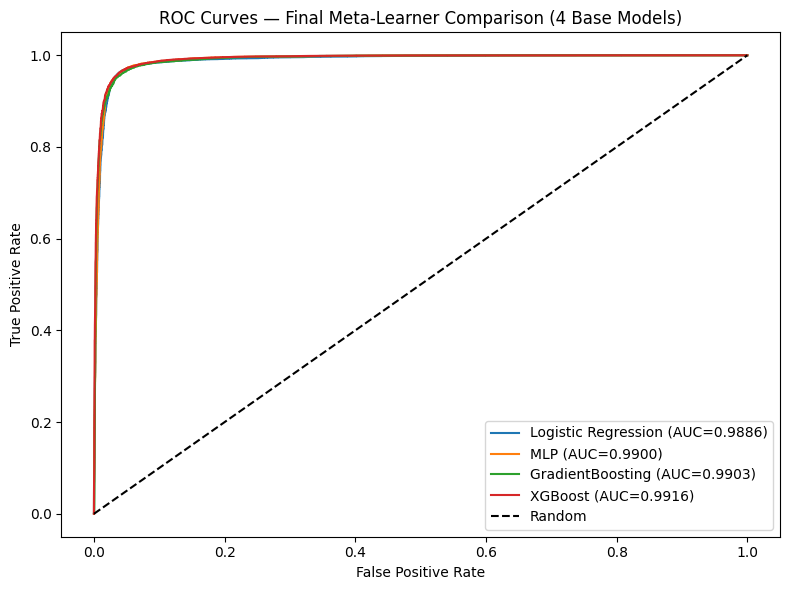

✓ ROC curves saved.


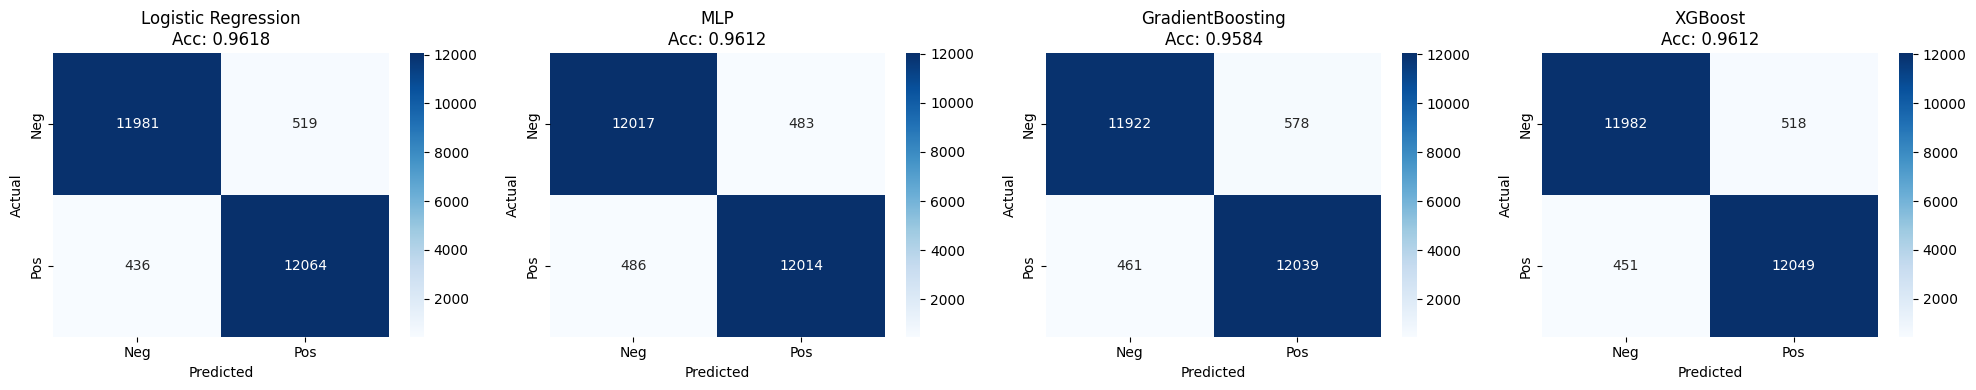

✓ Confusion matrices saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

models_list = [
    ("Logistic Regression", lr_preds,  lr_probs),
    ("MLP",                 mlp_preds, mlp_probs),
    ("GradientBoosting",    gb_preds,  gb_probs),
    ("XGBoost",             xgb_preds, xgb_probs),
]

# ROC Curves
plt.figure(figsize=(8, 6))
for name, preds, probs in models_list:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Final Meta-Learner Comparison (4 Base Models)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{DIRS['results']}/roc_curves_final_4models.png", dpi=150)
plt.show()
print("✓ ROC curves saved.")

# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, preds, probs) in zip(axes, models_list):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg", "Pos"],
                yticklabels=["Neg", "Pos"])
    ax.set_title(f"{name}\nAcc: {accuracy_score(y_test, preds):.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{DIRS['results']}/confusion_matrices_final_4models.png", dpi=150)
plt.show()
print("✓ Confusion matrices saved.")